## Data Loading & Preprocessing

# Smart Medical Analytics

This demonstrates core supervised and unsupervised machine learning techniques using healthcare datasets. It covers preprocessing, regression, classification, text classification, clustering, and dimensionality reduction to predict medical outcomes and segment patients.

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix
)
from scipy.cluster.hierarchy import linkage
import warnings
warnings.filterwarnings('ignore')

In [51]:
def create_preprocessor(X):
    numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
    
    transformers = []
    
    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])
    transformers.append(("num", numeric_pipeline, numeric_cols))
    
    if categorical_cols:
        categorical_pipeline = Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        ])
        transformers.append(("cat", categorical_pipeline, categorical_cols))
    
    return ColumnTransformer(transformers, remainder="drop")

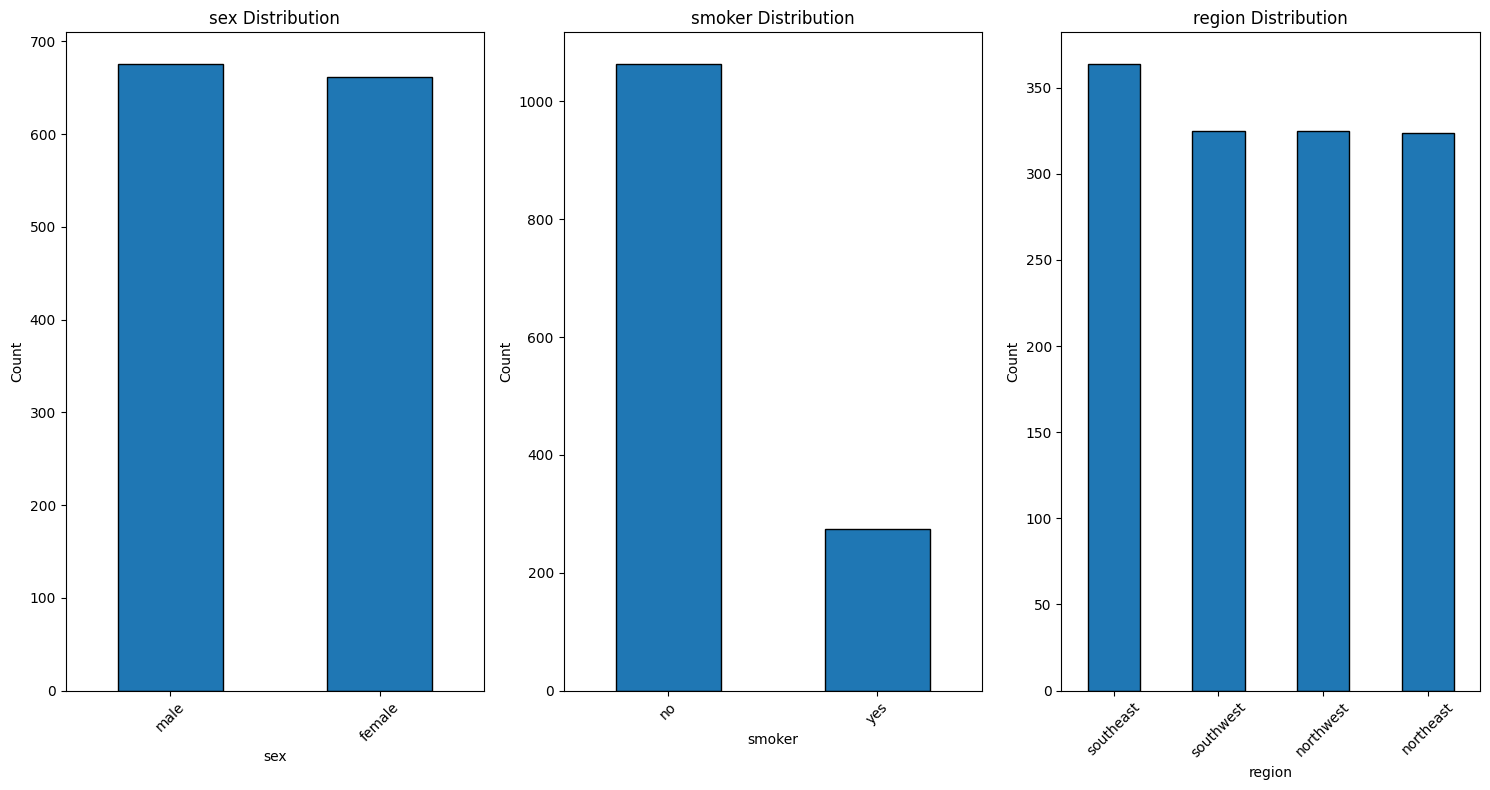

In [52]:
categorical_insurance = insurance_df.select_dtypes(include=['object']).columns

fig, axes = plt.subplots(1, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, col in enumerate(categorical_insurance):
    insurance_df[col].value_counts().plot(kind='bar', ax=axes[idx], edgecolor='black')
    axes[idx].set_title(f'{col} Distribution')
    axes[idx].set_ylabel('Count')
    axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

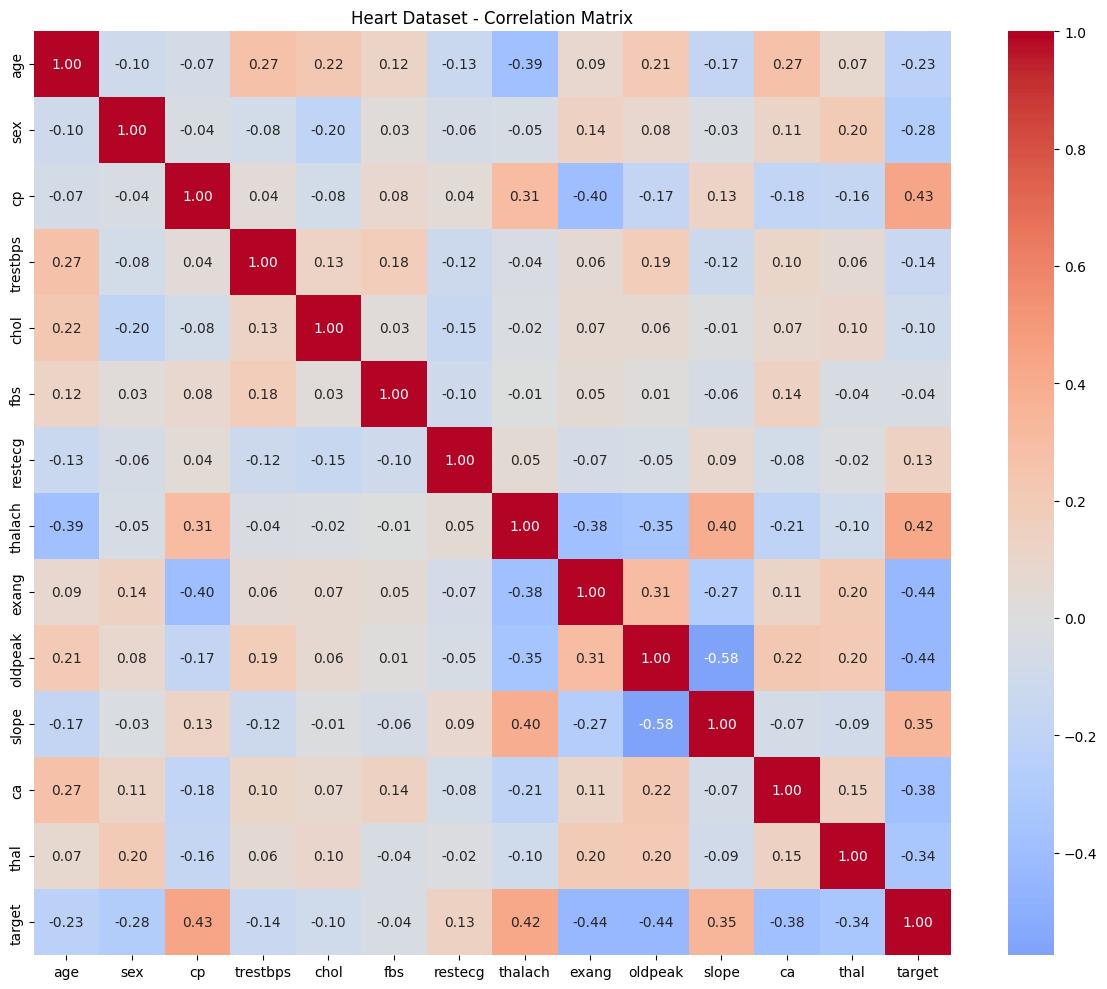

In [53]:
numeric_heart_all = heart_df.select_dtypes(include=['int64', 'float64'])
corr_heart = numeric_heart_all.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_heart, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Heart Dataset - Correlation Matrix')
plt.tight_layout()
plt.show()

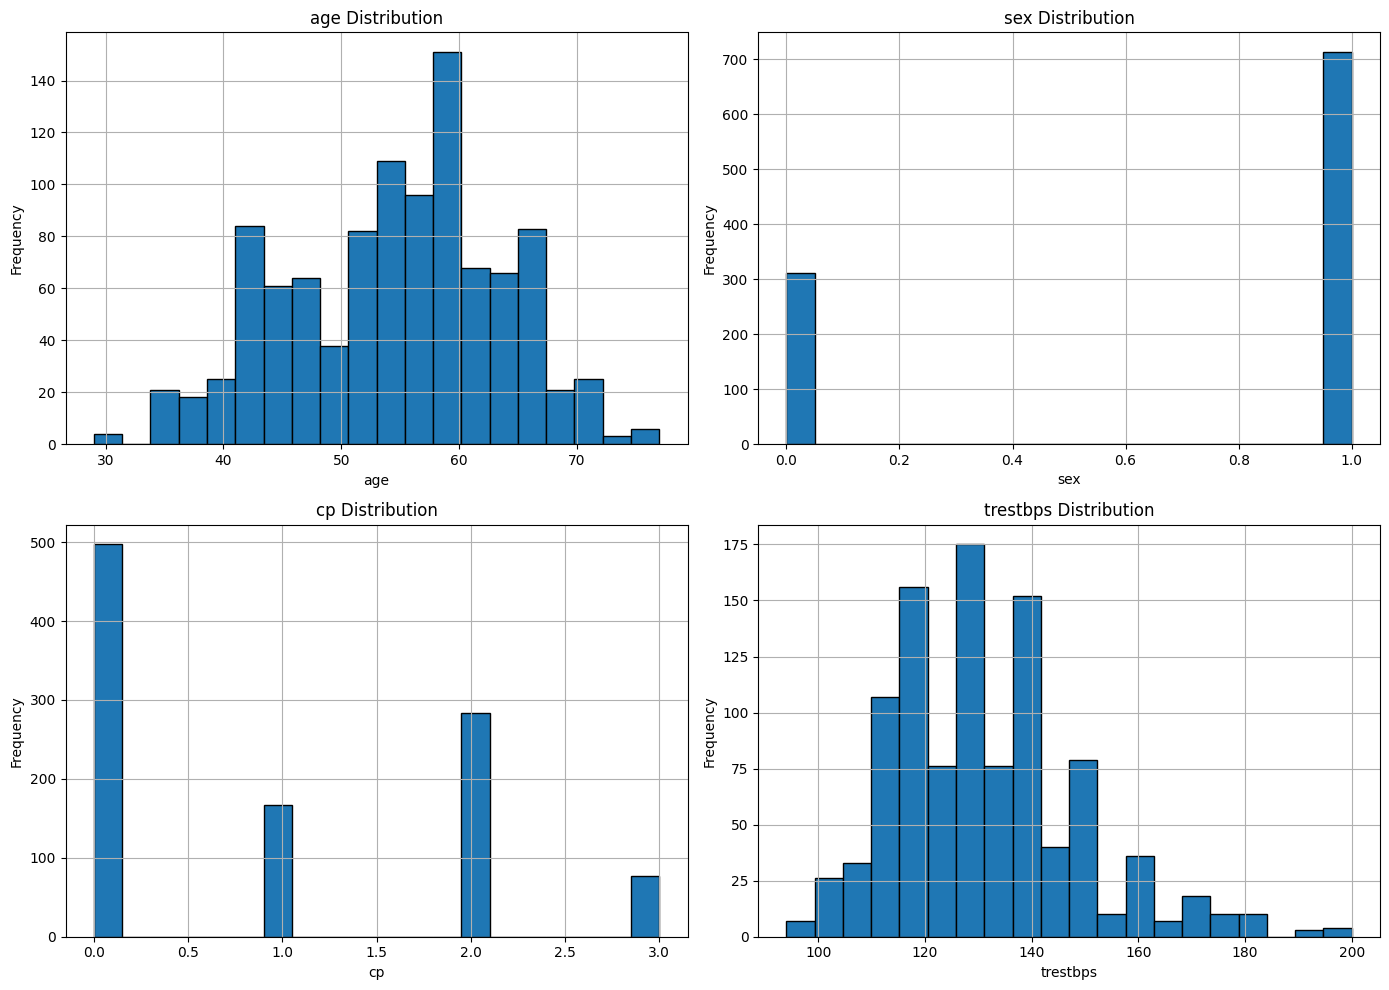

In [54]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

numeric_heart = heart_df.select_dtypes(include=['int64', 'float64']).columns[:4]

for idx, col in enumerate(numeric_heart):
    row = idx // 2
    col_idx = idx % 2
    heart_df[col].hist(bins=20, ax=axes[row, col_idx], edgecolor='black')
    axes[row, col_idx].set_title(f'{col} Distribution')
    axes[row, col_idx].set_xlabel(col)
    axes[row, col_idx].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

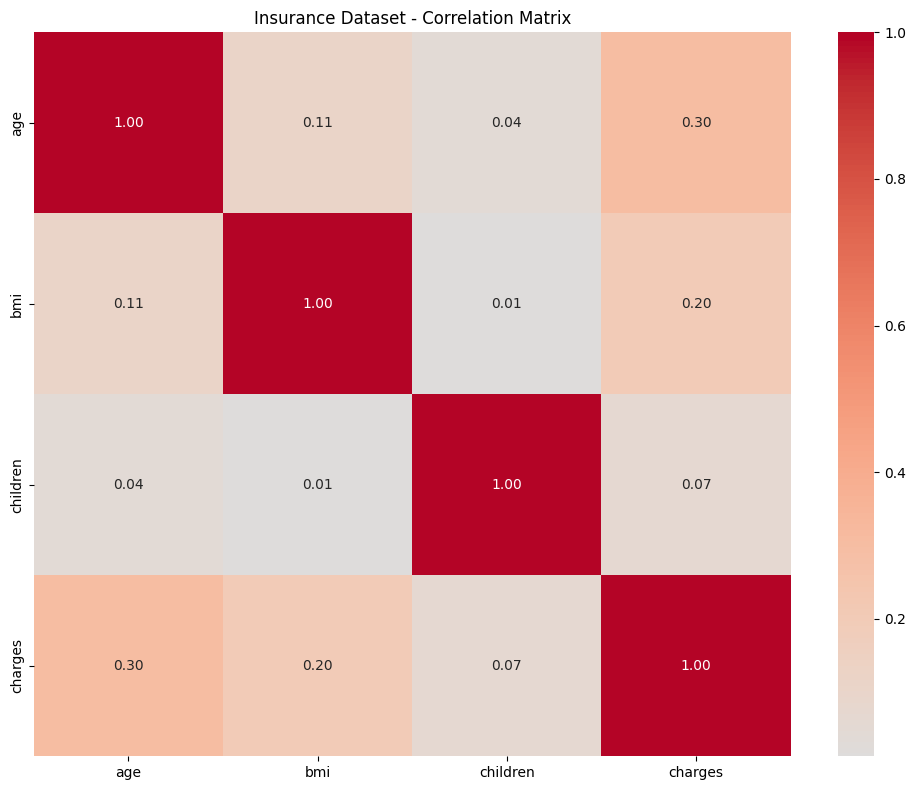

In [55]:
numeric_insurance = insurance_df.select_dtypes(include=['int64', 'float64'])
correlation_matrix = numeric_insurance.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Insurance Dataset - Correlation Matrix')
plt.tight_layout()
plt.show()

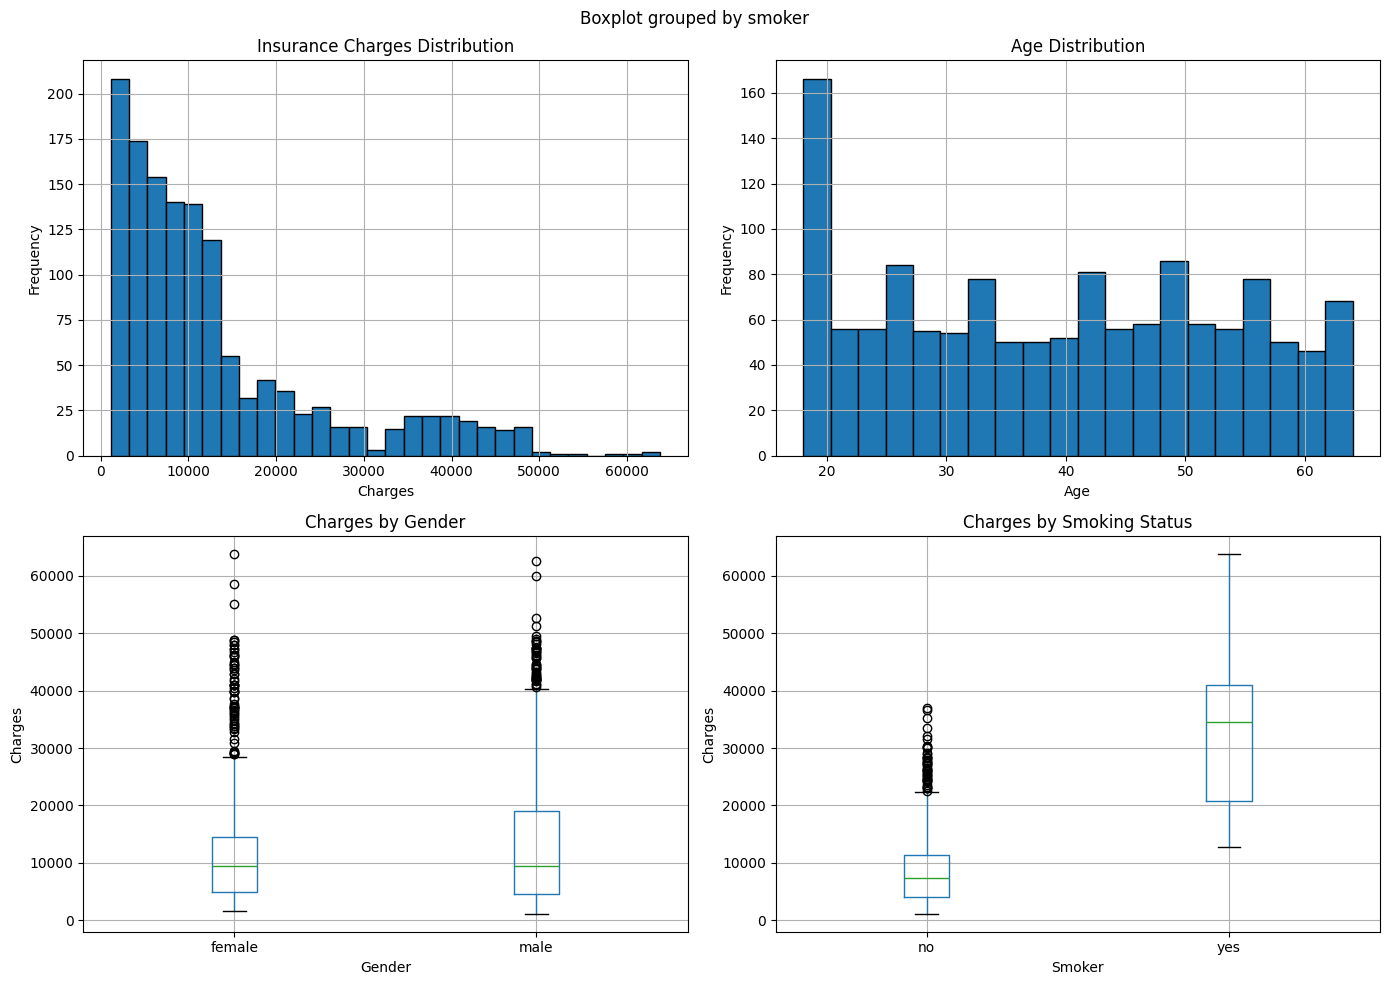

In [56]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

insurance_df['charges'].hist(bins=30, ax=axes[0, 0], edgecolor='black')
axes[0, 0].set_title('Insurance Charges Distribution')
axes[0, 0].set_xlabel('Charges')
axes[0, 0].set_ylabel('Frequency')

insurance_df['age'].hist(bins=20, ax=axes[0, 1], edgecolor='black')
axes[0, 1].set_title('Age Distribution')
axes[0, 1].set_xlabel('Age')
axes[0, 1].set_ylabel('Frequency')

insurance_df.boxplot(column='charges', by='sex', ax=axes[1, 0])
axes[1, 0].set_title('Charges by Gender')
axes[1, 0].set_xlabel('Gender')
axes[1, 0].set_ylabel('Charges')

insurance_df.boxplot(column='charges', by='smoker', ax=axes[1, 1])
axes[1, 1].set_title('Charges by Smoking Status')
axes[1, 1].set_xlabel('Smoker')
axes[1, 1].set_ylabel('Charges')

plt.tight_layout()
plt.show()

In [57]:
print("Heart Dataset Missing Values:")
print(heart_df.isnull().sum())

print("\n" + "="*50)
print("Symptom Description Dataset Shape:", symptom_desc_df.shape)
print("Symptom Description Dataset Info:")
print(symptom_desc_df.info())

Heart Dataset Missing Values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Symptom Description Dataset Shape: (41, 2)
Symptom Description Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41 entries, 0 to 40
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Disease      41 non-null     object
 1   Description  41 non-null     object
dtypes: object(2)
memory usage: 788.0+ bytes
None


In [58]:
print("\nInsurance Dataset Missing Values:")
print(insurance_df.isnull().sum())

print("\n" + "="*50)
print("Heart Dataset Info:")
print(heart_df.info())
print("\n" + "="*50)
print("Heart Dataset Statistics:")
print(heart_df.describe())


Insurance Dataset Missing Values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Heart Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB
None

Heart Dataset Statistics:
               ag

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Insurance Dataset Info:")
print(insurance_df.info())
print("\n" + "="*50)
print("Insurance Dataset Statistics:")
print(insurance_df.describe())

Insurance Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None

Insurance Dataset Statistics:
               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%    

## Exploratory Data Analysis (EDA)

In [60]:
X_reg = insurance_df.drop(columns=["charges"])
y_reg = insurance_df["charges"]

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

preprocessor_reg = create_preprocessor(X_train_reg)
reg_model = Pipeline([
    ("preprocessor", preprocessor_reg),
    ("regressor", LinearRegression()),
])
reg_model.fit(X_train_reg, y_train_reg)

y_pred_reg = reg_model.predict(X_test_reg)

mae = mean_absolute_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
r2 = r2_score(y_test_reg, y_pred_reg)

print("Multiple Linear Regression Metrics:")
print(f"  MAE: ${mae:,.0f}")
print(f"  RMSE: ${rmse:,.0f}")
print(f"  R² Score: {r2:.3f}")

Multiple Linear Regression Metrics:
  MAE: $4,181
  RMSE: $5,796
  R² Score: 0.784


In [61]:
## 2. Logistic Regression - Disease Risk Prediction

In [62]:
target_col = None
for col in heart_df.columns:
    unique_vals = heart_df[col].dropna().unique()
    if len(unique_vals) == 2:
        target_col = col
        break

print(f"Target column: {target_col}")

X_clf = heart_df.drop(columns=[target_col])
y_clf = heart_df[target_col]

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)

preprocessor_clf = create_preprocessor(X_train_clf)
clf_model = Pipeline([
    ("preprocessor", preprocessor_clf),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42)),
])
clf_model.fit(X_train_clf, y_train_clf)

y_pred_clf = clf_model.predict(X_test_clf)
y_proba_clf = clf_model.predict_proba(X_test_clf)[:, 1]

accuracy = accuracy_score(y_test_clf, y_pred_clf)
precision = precision_score(y_test_clf, y_pred_clf, zero_division=0)
recall = recall_score(y_test_clf, y_pred_clf, zero_division=0)
f1 = f1_score(y_test_clf, y_pred_clf, zero_division=0)

print("Logistic Regression Metrics:")
print(f"  Accuracy: {accuracy:.1%}")
print(f"  Precision: {precision:.1%}")
print(f"  Recall: {recall:.1%}")
print(f"  F1 Score: {f1:.3f}")

if len(np.unique(y_test_clf)) == 2:
    roc_auc = roc_auc_score(y_test_clf, y_proba_clf)
    print(f"  ROC AUC: {roc_auc:.3f}")

cm = confusion_matrix(y_test_clf, y_pred_clf)
print(f"\nConfusion Matrix:\n{cm}")

Target column: sex
Logistic Regression Metrics:
  Accuracy: 70.2%
  Precision: 72.7%
  Recall: 89.9%
  F1 Score: 0.804
  ROC AUC: 0.811

Confusion Matrix:
[[ 19  47]
 [ 14 125]]


In [63]:
## 3. Naive Bayes - Text Classification

In [64]:
text_col = symptom_desc_df.columns[0]
label_col = symptom_desc_df.columns[1]

X_nb = symptom_desc_df[text_col].astype(str)
y_nb = symptom_desc_df[label_col]

X_train_nb, X_test_nb, y_train_nb, y_test_nb = train_test_split(X_nb, y_nb, test_size=0.2, random_state=42)

nb_model = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words="english")),
    ("classifier", MultinomialNB()),
])
nb_model.fit(X_train_nb, y_train_nb)

y_pred_nb = nb_model.predict(X_test_nb)
accuracy_nb = accuracy_score(y_test_nb, y_pred_nb)

print("Naive Bayes Text Classification Metrics:")
print(f"  Accuracy: {accuracy_nb:.3f}")
print(f"  Text column: {text_col}")
print(f"  Label column: {label_col}")

Naive Bayes Text Classification Metrics:
  Accuracy: 0.000
  Text column: Disease
  Label column: Description


In [65]:
## 4. Clustering Analysis

In [66]:
X_clust = heart_df.drop(columns=[target_col])
preprocessor_clust = create_preprocessor(X_clust)
features_heart = preprocessor_clust.fit_transform(X_clust)

print(f"Clustering features shape: {features_heart.shape}")

inertias = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(features_heart)
    inertias.append(kmeans.inertia_)

print("\nK-Means Elbow Method:")
for k, inertia in enumerate(inertias, 2):
    print(f"  Clusters: {k}, Inertia: {inertia:.2f}")

Clustering features shape: (1025, 13)

K-Means Elbow Method:
  Clusters: 2, Inertia: 10809.79
  Clusters: 3, Inertia: 9997.95
  Clusters: 4, Inertia: 9440.42
  Clusters: 5, Inertia: 9065.53
  Clusters: 6, Inertia: 8629.41
  Clusters: 7, Inertia: 8295.22
  Clusters: 8, Inertia: 7998.18
  Clusters: 9, Inertia: 7755.11
  Clusters: 10, Inertia: 7562.19


In [67]:
### K-Means Clustering Metrics

In [68]:
kmeans_model = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans_model.fit_predict(features_heart)

print("K-Means Clustering (k=3) Metrics:")
print(f"  Cluster distribution: {np.bincount(kmeans_labels)}")
print(f"  Inertia: {kmeans_model.inertia_:.2f}")

K-Means Clustering (k=3) Metrics:
  Cluster distribution: [419 348 258]
  Inertia: 9997.95


In [69]:
### Hierarchical Clustering Metrics

In [70]:
hierarchical_model = AgglomerativeClustering(n_clusters=3)
hierarchical_labels = hierarchical_model.fit_predict(features_heart)

print("Hierarchical Clustering (k=3) Metrics:")
print(f"  Cluster distribution: {np.bincount(hierarchical_labels)}")

Hierarchical Clustering (k=3) Metrics:
  Cluster distribution: [514 358 153]


In [73]:
pca_model = PCA(n_components=2, random_state=42)
pca_features = pca_model.fit_transform(features_heart)

print("PCA Dimensionality Reduction Metrics:")
print(f"  Original features: {features_heart.shape[1]}")
print(f"  Reduced features: {pca_features.shape[1]}")
print(f"  Explained variance ratio: {pca_model.explained_variance_ratio_}")
print(f"  Cumulative explained variance: {np.sum(pca_model.explained_variance_ratio_):.3f}")

PCA Dimensionality Reduction Metrics:
  Original features: 13
  Reduced features: 2
  Explained variance ratio: [0.25268576 0.11522172]
  Cumulative explained variance: 0.368


## Summary Report

In [ ]:
print("\n=== ANALYSIS SUMMARY ===")
print(f"\nDatasets Loaded:")
print(f"  Insurance: {insurance_df.shape}")
print(f"  Heart: {heart_df.shape}")
print(f"  Symptom Descriptions: {symptom_desc_df.shape}")

print(f"\n1. Multiple Linear Regression:")
print(f"  R² Score: {r2:.3f}")
print(f"  MAE: ${mae:,.0f}")
print(f"  RMSE: ${rmse:,.0f}")

print(f"\n2. Logistic Regression:")
print(f"  Accuracy: {accuracy:.1%}")
print(f"  F1 Score: {f1:.3f}")
print(f"  ROC AUC: {roc_auc:.3f}")

print(f"\n3. Naive Bayes Text Classification:")
print(f"  Accuracy: {accuracy_nb:.3f}")

print(f"\n4. Clustering Results:")
print(f"  K-Means (k=3): {len(np.unique(kmeans_labels))} clusters")
print(f"  Hierarchical (k=3): {len(np.unique(hierarchical_labels))} clusters")
print(f"  PCA variance explained: {np.sum(pca_model.explained_variance_ratio_):.3f}")

print("\nAnalysis Complete")


=== ANALYSIS SUMMARY ===

Datasets Loaded:
  Insurance: (1338, 7)
  Heart: (1025, 14)
  Symptom Descriptions: (41, 2)

1. Multiple Linear Regression:
  R² Score: 0.784
  MAE: $4,181
  RMSE: $5,796

2. Logistic Regression:
  Accuracy: 70.2%
  F1 Score: 0.804
  ROC AUC: 0.811

3. Naive Bayes Text Classification:
  Accuracy: 0.000

4. Clustering Results:
  K-Means (k=3): 3 clusters
  Hierarchical (k=3): 3 clusters
  DBSCAN: 6 clusters, 299 noise points
  PCA variance explained: 0.368

Analysis Complete


### PCA Dimensionality Reduction

In [75]:
pca_model = PCA(n_components=2, random_state=42)
pca_features = pca_model.fit_transform(features_heart)

print("PCA Dimensionality Reduction Metrics:")
print(f"  Original features: {features_heart.shape[1]}")
print(f"  Reduced features: {pca_features.shape[1]}")
print(f"  Explained variance ratio: {pca_model.explained_variance_ratio_}")
print(f"  Cumulative explained variance: {np.sum(pca_model.explained_variance_ratio_):.3f}")

PCA Dimensionality Reduction Metrics:
  Original features: 13
  Reduced features: 2
  Explained variance ratio: [0.25268576 0.11522172]
  Cumulative explained variance: 0.368
